<a href="https://colab.research.google.com/github/sanvisinghal/CODSOFT/blob/main/RMTWFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn nltk spacy wordcloud gensim bertopic sentence-transformers umap-learn hdbscan openpyxl
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving 4.18.csv to 4.18.csv
Uploaded file: 4.18.csv


In [ ]:
df = pd.read_csv(filename, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
print(df.info())

missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame("missing_count"))
print("Duplicate rows:", df.duplicated().sum())

if "Title" in df.columns:
    print("Duplicate titles:", df["Title"].duplicated().sum())

Dataset shape: (1558, 5)

Columns:
['Title', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']


,Title,Link,Abstract,Author Keywords,Index Keywords
0,Chronic C-S-Fe defense dominance over nutrient removal in nanoplastics-exposed constructed wetlands: persistent feoA as the core biomarker,https://www.scopus.com/pages/publications/105025422272?origin=resultslist,"Constructed wetlands (CWs) face intensifying threats from nanoplastics (NPs). While existing evidence confirmed NPs impaired pollutant removal by disrupting microbial metabolism, critical knowledg...",C-N-P-S-Fe cycle; Constructed wetlands; Microbial community; Nanoplastics; Pollutant removal,Biogeochemistry; Ecosystems; Environmental management; Investments; Iron compounds; Metabolism; Microorganisms; Nitrogen removal; Physiology; Pollution control; Pollution detection; Wetlands; C-N-...
1,Synergistic multi-site engineering of bound exciton relays for near-unity PLQY and stable NIR emission in lead-free perovskite inspired 0D metal halides,https://www.scopus.com/pages/publications/105040084278?origin=resultslist,Efficient near-infrared (NIR) emission in lead-free perovskite-inspired 0D metal halides remains constrained by non-radiative losses and a fundamental limitation to singular energy transfer pathwa...,0D Metal Halides; Bound Exciton; High PLQY; Lead Free Perovskites; Multi-doping; NIR Emission; Solvothermal Synthesis,Antimony compounds; Bromine compounds; Cesium compounds; Defects; Ecosystems; Energy transfer; Excited states; Excitons; Harvesting; Infrared devices; Lead compounds; Metal drawing; Niobium compou...
2,"The Fading Gulf: Morphological Transformations, Cyclone Footprints, and Land Use Dynamics Threatening Long-Term Resilience for Gulf of Mannar Coastal Islands",https://www.scopus.com/pages/publications/105045065656?origin=resultslist,"This study investigates dynamic morphological processes, cyclone-induced shoreline migrations, and land-use/land-cover (LULC) characteristics in the region of Gulf of Mannar Islands between southe...",Anthropogenic pressures; Ecological indicators; Fragile Island; Gulf of Mannar Islands; Imaging; LULC; Sensing,Anthropogenic; Biodiversity; Ecosystems; Hurricanes; Land use; Landforms; Linear regression; Satellites; Shore protection; Storms; Anthropogenic pressures; Ecological indicators; Fragile island; G...
3,HyWaThy: Hybrid modeling of nearshore Waves with different baThymetric states,https://www.scopus.com/pages/publications/105011366718?origin=resultslist,"Coastal areas such as sandy beaches are highly pressured environments by humans worldwide, as they provide a wide range of ecosystem services that directly benefit societies. The growing concentra...",Bathymetries; Hybrid methodology; Hydrodynamics; Nearshore waves; XBeach non hydrostatic,Beaches; Coastal engineering; Coastal zones; Data flow analysis; Ecosystems; Hydraulics; Hydrographic surveys; Offshore oil well production; Principal component analysis; Sediment transport; Water...
4,A Multifactor Harmonized Vegetation Index Compositing (MHVC) Approach for Monitoring Vegetation Dynamics in Sandy Land Ecosystems With Landsat-8/9 and Sentinel-2,https://www.scopus.com/pages/publications/105044371861?origin=resultslist,"ccurate monitoring of vegetation dynamics in optically complex sandy land ecosystems requires high-spatiotemporal-resolution time series, yet generating such records from individual sensors remain...",Data harmonization; Landsat-8/9; Multifactor Harmonized Vegetation index Compositing (MHVC); sandy land; Sentinel-2,China; Ordos; Aerosols; Clouds; Dust; Ecosystems; Filtration; Forestry; Landsat; Median filters; Radiometry; Reflection; Sand; Vegetation; Compositing; Data harmonization; LANDSAT; Landsat-8/9; Mu...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            1558 non-null   object
 1   Link             1558 non-null   object
 2   Abstract         1558 non-null   object
 3   Author Keywords  1503 non-null   object
 4   Index Keywords   1546 non-null   object
dtypes: object(5)
memory usage: 61.0+ KB
None


,missing_count
Author Keywords,55
Index Keywords,12
Title,0
Abstract,0
Link,0


Duplicate rows: 0
Duplicate titles: 0


In [ ]:
df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

required_columns = ["Title", "Abstract"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Required column missing: {column}")

text_columns = [
    "Title",
    "Abstract",
    "Author Keywords",
    "Index Keywords"
]

for column in text_columns:
    if column in df.columns:
        df[column] = df[column].fillna("").astype(str)

df = df.drop_duplicates(subset="Title").reset_index(drop=True)

df["text"] = (
    df["Title"] + " " +
    df["Abstract"] + " " +
    df.get("Author Keywords", "") + " " +
    df.get("Index Keywords", "")
)

df["abstract_text"] = df["Abstract"]

print("Rows after duplicate removal:", len(df))

Rows after duplicate removal: 1558


In [ ]:
year_column_candidates = [
    "Year",
    "Publication Year",
    "Published",
    "Date"
]

year_column = next(
    (column for column in year_column_candidates if column in df.columns),
    None
)

if year_column:
    df["Year"] = pd.to_numeric(
        df[year_column].astype(str).str.extract(r"(19\d{2}|20\d{2})")[0],
        errors="coerce"
    )
else:
    df["Year"] = pd.to_numeric(
        df["text"].str.extract(r"\b(19\d{2}|20\d{2})\b")[0],
        errors="coerce"
    )

print("Year values found:", df["Year"].notna().sum())
display(df["Year"].value_counts(dropna=False).sort_index())

Year values found: 1539


,count
Year,
1900.0,1
1914.0,1
1922.0,1
1955.0,1
1960.0,3
...,...
2048.0,1
2050.0,7
2070.0,2


In [ ]:
country_names = [
    "China", "India", "Japan", "Indonesia", "Turkey", "Canada",
    "Ghana", "Spain", "Portugal", "Taiwan", "Australia", "Brazil",
    "United States", "USA", "United Kingdom", "UK", "Germany",
    "France", "Italy", "Pakistan", "Bangladesh", "Malaysia",
    "Singapore", "Thailand", "Vietnam", "South Korea", "Russia",
    "Mexico", "South Africa", "Nigeria", "Iran", "Iraq",
    "Saudi Arabia", "New Zealand", "Netherlands", "Switzerland",
    "Poland", "Norway", "Sweden", "Finland", "Denmark",
    "Austria", "Belgium", "Greece", "Egypt", "Morocco",
    "Nepal", "Sri Lanka"
]

def extract_country(text):
    found = []
    text_lower = text.lower()

    for country in country_names:
        if re.search(r"\b" + re.escape(country.lower()) + r"\b", text_lower):
            found.append(country)

    return found[0] if found else "Unknown"

df["Country"] = df["text"].apply(extract_country)

print("Country distribution:")
display(df["Country"].value_counts().head(20))

Country distribution:


,count
Country,
Unknown,862
China,356
India,43
United States,38
Iran,21
UK,20
Italy,17
Spain,16
Switzerland,16


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

custom_stopwords = {
    "study", "paper", "research", "result", "results",
    "method", "methods", "using", "used", "based",
    "show", "shows", "shown", "include", "including",
    "provide", "provided", "propose", "proposed",
    "aim", "aims", "find", "finding", "findings"
}

scientific_keep_words = {
    "nlp", "bert", "lda", "nmf", "gis", "ndvi",
    "landsat", "sentinel", "xgboost", "random",
    "forest", "ecosystem", "climate", "remote",
    "sensing", "microbial", "wetland"
}

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\([^)]*\)", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)
    tokens = []

    for token in doc:
        word = token.lemma_.lower().strip()

        if (
            len(word) > 2
            and not token.is_stop
            and not token.like_num
            and (token.is_alpha or word in scientific_keep_words)
            and word not in custom_stopwords
        ):
            tokens.append(word)

    return tokens

df["tokens"] = df["text"].apply(preprocess_text)
df["clean_text"] = df["tokens"].apply(" ".join)

df["word_count"] = df["clean_text"].str.split().str.len()
df["character_count"] = df["clean_text"].str.len()

display(df[["Title", "word_count", "clean_text"]].head())

,Title,word_count,clean_text
0,Chronic C-S-Fe defense dominance over nutrient removal in nanoplastics-exposed constructed wetlands: persistent feoA as the core biomarker,217,chronic defense dominance nutrient removal nanoplastics expose construct wetland persistent feoa core biomarker construct wetland face intensify threat nanoplastic existing evidence confirm nps im...
1,Synergistic multi-site engineering of bound exciton relays for near-unity PLQY and stable NIR emission in lead-free perovskite inspired 0D metal halides,300,synergistic multi site engineering bound exciton relay near unity plqy stable nir emission lead free perovskite inspire metal halide efficient near infrared emission lead free perovskite inspire m...
2,"The Fading Gulf: Morphological Transformations, Cyclone Footprints, and Land Use Dynamics Threatening Long-Term Resilience for Gulf of Mannar Coastal Islands",240,fading gulf morphological transformation cyclone footprint land use dynamic threaten long term resilience gulf mannar coastal island investigate dynamic morphological process cyclone induce shorel...
3,HyWaThy: Hybrid modeling of nearshore Waves with different baThymetric states,230,hywathy hybrid modeling nearshore wave different bathymetric state coastal area sandy beach highly pressured environment human worldwide wide range ecosystem service directly benefit society grow ...
4,A Multifactor Harmonized Vegetation Index Compositing (MHVC) Approach for Monitoring Vegetation Dynamics in Sandy Land Ecosystems With Landsat-8/9 and Sentinel-2,324,multifactor harmonize vegetation index compositing approach monitor vegetation dynamic sandy land ecosystem ccurate monitoring vegetation dynamic optically complex sandy land ecosystem require hig...


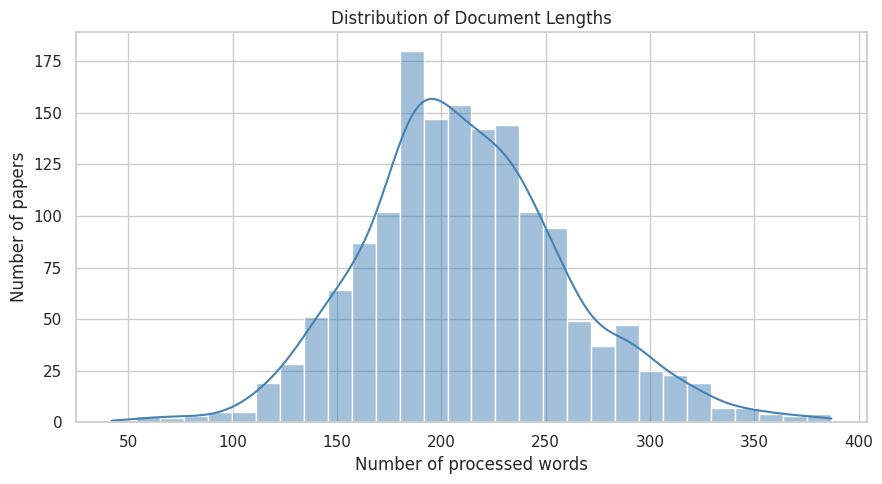

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Document Lengths")
plt.xlabel("Number of processed words")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

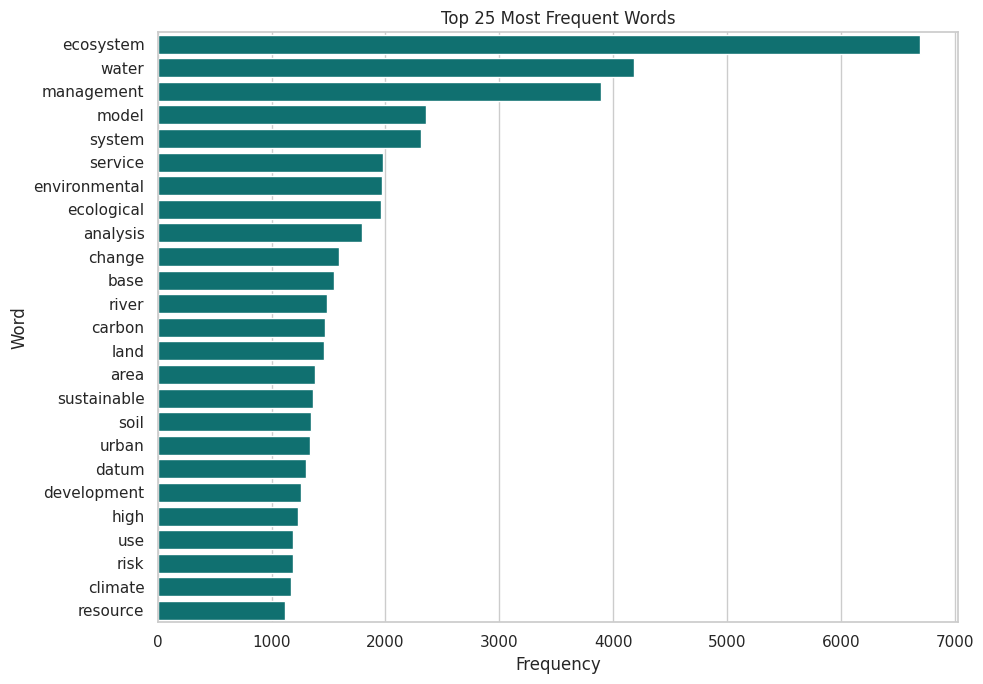

,Word,Frequency
0,ecosystem,6699
1,water,4186
2,management,3890
3,model,2354
4,system,2310
5,service,1982
6,environmental,1971
7,ecological,1964
8,analysis,1796
9,change,1588


In [ ]:
word_counter = Counter(
    word for tokens in df["tokens"] for word in tokens
)

top_words = pd.DataFrame(
    word_counter.most_common(25),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    y="Word",
    x="Frequency",
    color="teal"
)

plt.title("Top 25 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

display(top_words)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_table = pd.DataFrame({
    "Term": tfidf_terms,
    "TF_IDF_Score": tfidf_scores
}).sort_values("TF_IDF_Score", ascending=False)

display(tfidf_table.head(30))

TF-IDF matrix shape: (1558, 10000)


,Term,TF_IDF_Score
9733,water,0.023215
5708,model,0.019921
8890,system,0.019754
8007,service,0.018853
3094,environmental,0.018568
316,analysis,0.017845
2534,ecological,0.017373
727,base,0.016745
1207,change,0.016670
8827,sustainable,0.016080


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    ngram_range=(1, 2),
    max_features=10000
)

count_matrix = count_vectorizer.fit_transform(df["clean_text"])
count_terms = count_vectorizer.get_feature_names_out()

print("Count matrix shape:", count_matrix.shape)

Count matrix shape: (1558, 10000)


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

topic_range = range(2, 13)

lda_models = {}
lda_perplexities = {}

for number_of_topics in topic_range:
    model = LatentDirichletAllocation(
        n_components=number_of_topics,
        random_state=42,
        learning_method="batch",
        max_iter=30,
        doc_topic_prior=0.1,
        topic_word_prior=0.01
    )

    model.fit(count_matrix)

    lda_models[number_of_topics] = model
    lda_perplexities[number_of_topics] = model.perplexity(count_matrix)

print("LDA models trained.")

LDA models trained.


In [ ]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

dictionary = Dictionary(df["tokens"].tolist())

corpus = [
    dictionary.doc2bow(tokens)
    for tokens in df["tokens"]
]

coherence_scores = {}

for number_of_topics, model in lda_models.items():
    topic_words = []

    for topic in model.components_:
        top_indices = topic.argsort()[-15:][::-1]
        words = [count_terms[index] for index in top_indices]
        topic_words.append(words)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=df["tokens"].tolist(),
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence_scores[number_of_topics] = coherence_model.get_coherence()

coherence_table = pd.DataFrame({
    "Number_of_Topics": list(coherence_scores.keys()),
    "Coherence": list(coherence_scores.values()),
    "Perplexity": [
        lda_perplexities[k] for k in coherence_scores.keys()
    ]
})

display(coherence_table)

,Number_of_Topics,Coherence,Perplexity
0,2,0.432559,3039.916754
1,3,0.426733,2839.965495
2,4,0.450596,2751.806312
3,5,0.498940,2582.564200
4,6,0.492468,2535.916735
5,7,0.504968,2492.197188
6,8,0.515054,2439.445845
7,9,0.484171,2384.595601
8,10,0.519418,2352.849057
9,11,0.509804,2335.796160


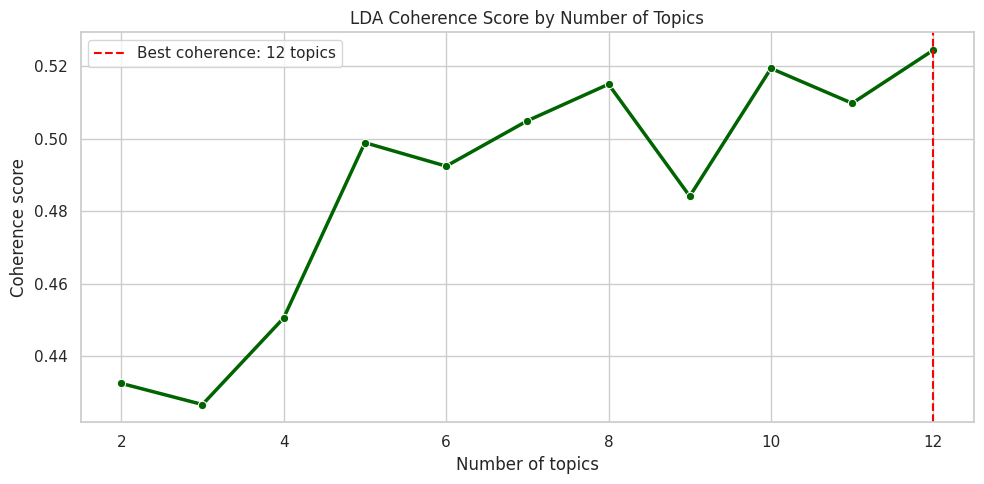

Best topic count according to coherence: 12


In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=coherence_table,
    x="Number_of_Topics",
    y="Coherence",
    marker="o",
    linewidth=2.5,
    color="darkgreen"
)

best_lda_topics = coherence_table.loc[
    coherence_table["Coherence"].idxmax(),
    "Number_of_Topics"
]

plt.axvline(
    best_lda_topics,
    color="red",
    linestyle="--",
    label=f"Best coherence: {int(best_lda_topics)} topics"
)

plt.title("LDA Coherence Score by Number of Topics")
plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.legend()
plt.tight_layout()
plt.show()

print("Best topic count according to coherence:", int(best_lda_topics))

In [ ]:
best_lda_topics = int(best_lda_topics)
best_lda_model = lda_models[best_lda_topics]

lda_doc_topic_matrix = best_lda_model.transform(count_matrix)

df["LDA_Topic"] = lda_doc_topic_matrix.argmax(axis=1) + 1
df["LDA_Topic_Probability"] = lda_doc_topic_matrix.max(axis=1)

print("Selected LDA topic count:", best_lda_topics)
def get_topic_words(model, feature_names, number_of_words=15):
    topic_rows = []

    for topic_number, topic in enumerate(model.components_, start=1):
        top_indices = topic.argsort()[-number_of_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]

        topic_rows.append({
            "Topic": topic_number,
            "Top_Words": ", ".join(top_words)
        })

    return pd.DataFrame(topic_rows)

lda_topic_words = get_topic_words(
    best_lda_model,
    count_terms,
    number_of_words=15
)

display(lda_topic_words)

Selected LDA topic count: 12


,Topic,Top_Words
0,1,"innovation, digital, technology, knowledge, model, decision, datum, system, business, base, process, development, analysis, platform, industry"
1,2,"urban, service, ecosystem service, green, sustainable, development, city, area, spatial, climate, analysis, china, sustainable development, base, planning"
2,3,"land, use, land use, change, service, forest, ecosystem service, wetland, environmental, cover, value, conservation, sustainable, model, impact"
3,4,"community, microbial, system, stability, dynamic, control, model, microbial community, interaction, effect, bifurcation, predator, functional, analysis, population"
4,5,"risk, pollution, ecological, assessment, environmental, risk assessment, health, water, wastewater, treatment, metal, source, ecological risk, chemical, high"
5,6,"model, learn, remote, machine, sense, learning, datum, remote sense, forest, deep, machine learn, network, accuracy, tree, satellite"
6,7,"system, energy, environmental, life, blockchain, base, cycle, impact, network, life cycle, cost, sustainable, security, smart, power"
7,8,"carbon, lake, nitrogen, nutrient, emission, organic, gas, phosphorus, sequestration, carbon sequestration, eutrophication, greenhouse, greenhouse gas, dissolve, matter"
8,9,"water, river, flow, basin, resource, water resource, water management, model, river basin, change, climate, groundwater, hydrological, analysis, system"
9,10,"soil, agricultural, vegetation, crop, increase, agriculture, high, yield, region, climate, forest, plant, production, water, restoration"


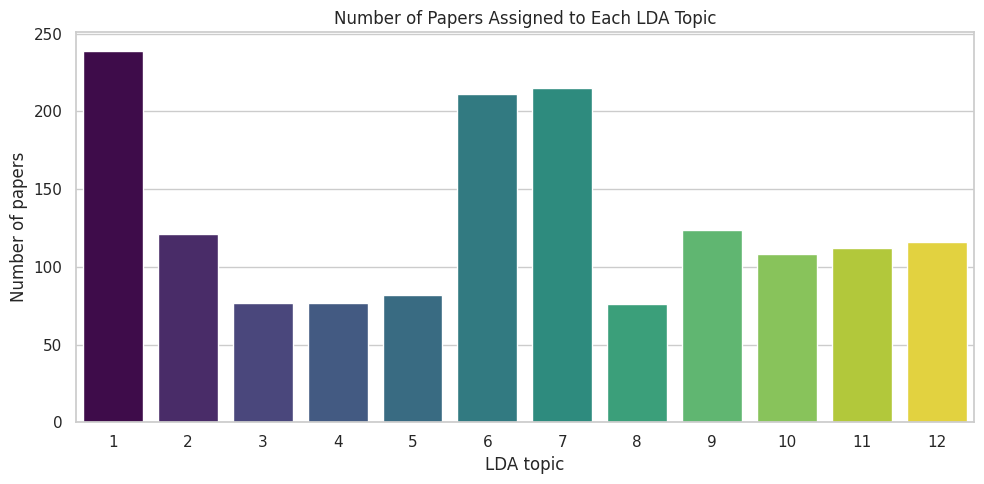

,Topic,Number_of_Papers
0,1,239
1,2,121
2,3,77
3,4,77
4,5,82
5,6,211
6,7,215
7,8,76
8,9,124
9,10,108


In [ ]:
topic_counts = (
    df["LDA_Topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_counts.columns = ["Topic", "Number_of_Papers"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=topic_counts,
    x="Topic",
    y="Number_of_Papers",
    hue="Topic",
    palette="viridis",
    legend=False
)

plt.title("Number of Papers Assigned to Each LDA Topic")
plt.xlabel("LDA topic")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

display(topic_counts)

In [ ]:
topic_labels = {
    topic: f"Topic {topic}"
    for topic in range(1, best_lda_topics + 1)
}

# Example:
# topic_labels = {
#     1: "Environmental Management",
#     2: "Remote Sensing",
#     3: "Climate and Ecosystems",
#     4: "Materials Science"
# }

df["LDA_Topic_Label"] = df["LDA_Topic"].map(topic_labels)

<Figure size 1300x600 with 0 Axes>

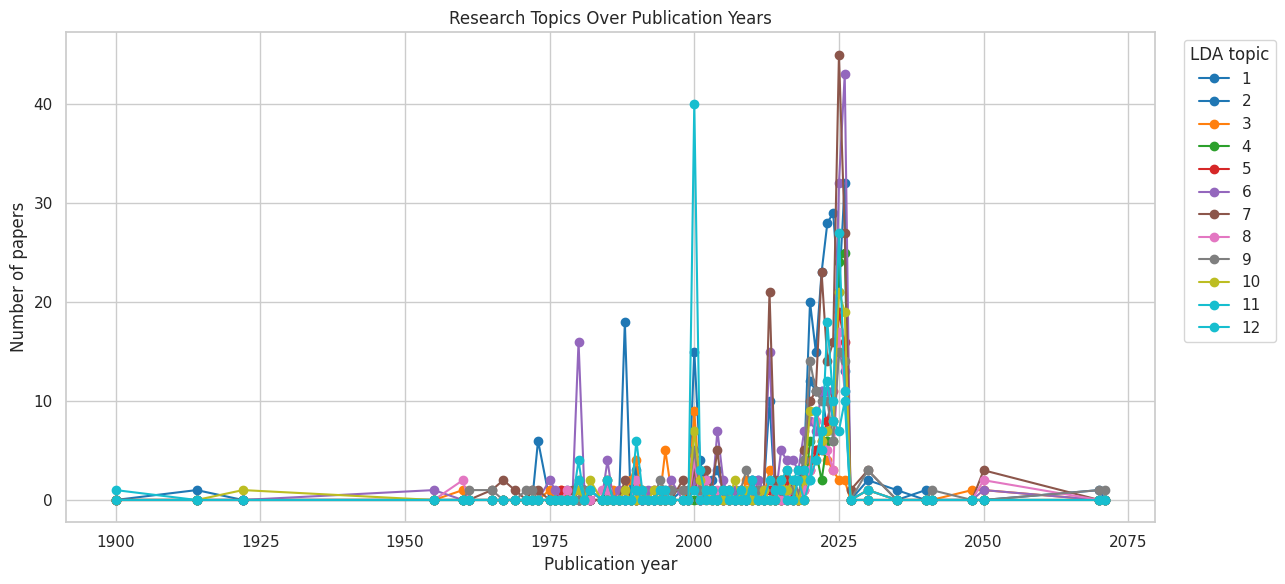

LDA_Topic,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
1900,0,0,0,0,0,0,0,0,0,0,1,0
1914,1,0,0,0,0,0,0,0,0,0,0,0
1922,0,0,0,0,0,0,0,0,0,1,0,0
1955,0,0,0,0,0,1,0,0,0,0,0,0
1960,0,0,1,0,0,0,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2041,0,0,0,0,0,0,0,0,1,0,0,0
2048,0,0,1,0,0,0,0,0,0,0,0,0
2050,0,0,1,0,0,1,3,2,0,0,0,0


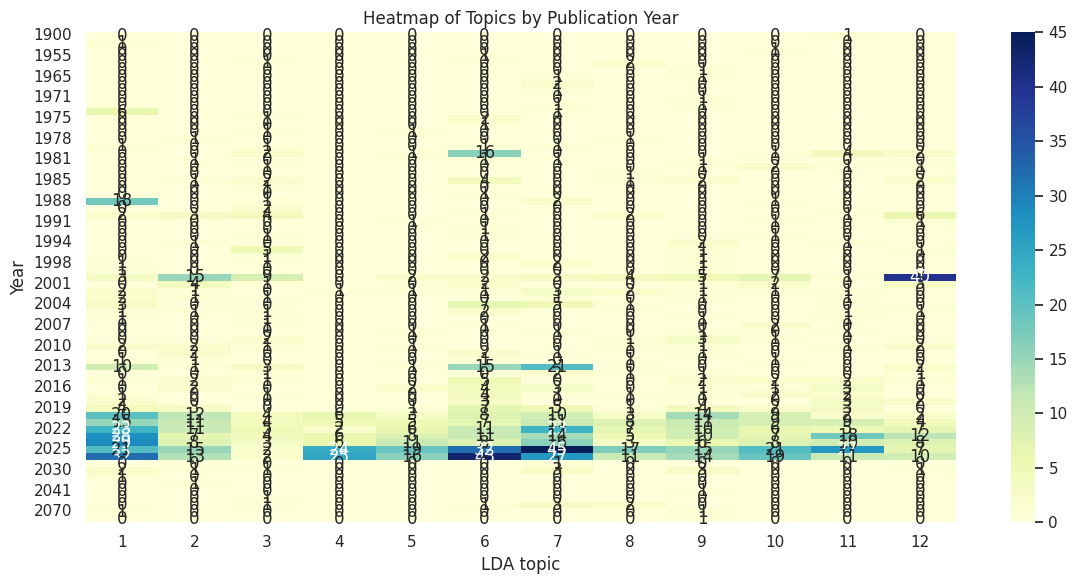

In [ ]:
year_topic_data = df.dropna(subset=["Year"]).copy()

if len(year_topic_data) > 0:
    year_topic_table = pd.crosstab(
        year_topic_data["Year"].astype(int),
        year_topic_data["LDA_Topic"]
    )

    plt.figure(figsize=(13, 6))

    year_topic_table.plot(
        kind="line",
        marker="o",
        figsize=(13, 6),
        colormap="tab10"
    )

    plt.title("Research Topics Over Publication Years")
    plt.xlabel("Publication year")
    plt.ylabel("Number of papers")
    plt.legend(title="LDA topic", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    display(year_topic_table)
else:
    print("No reliable year column was found.")
if len(year_topic_data) > 0:
    plt.figure(figsize=(12, 6))

    sns.heatmap(
        year_topic_table,
        annot=True,
        fmt="g",
        cmap="YlGnBu"
    )

    plt.title("Heatmap of Topics by Publication Year")
    plt.xlabel("LDA topic")
    plt.ylabel("Year")
    plt.tight_layout()
    plt.show()

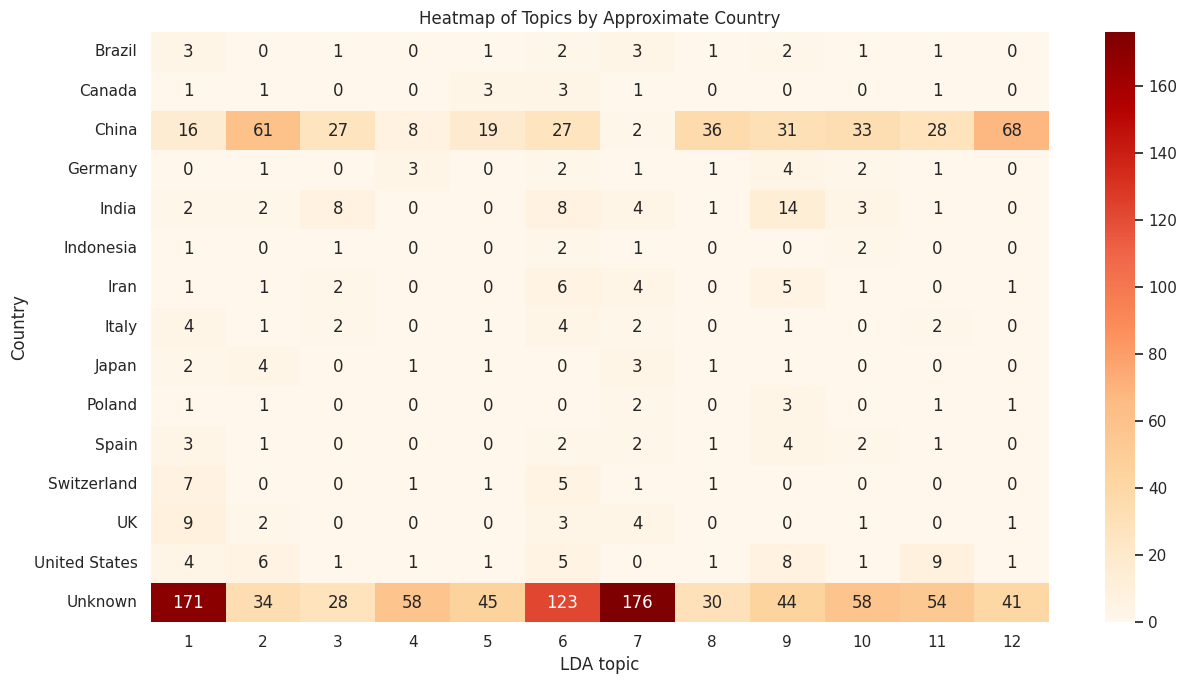

LDA_Topic,1,2,3,4,5,6,7,8,9,10,11,12
Country,,,,,,,,,,,,
Brazil,3,0,1,0,1,2,3,1,2,1,1,0
Canada,1,1,0,0,3,3,1,0,0,0,1,0
China,16,61,27,8,19,27,2,36,31,33,28,68
Germany,0,1,0,3,0,2,1,1,4,2,1,0
India,2,2,8,0,0,8,4,1,14,3,1,0
Indonesia,1,0,1,0,0,2,1,0,0,2,0,0
Iran,1,1,2,0,0,6,4,0,5,1,0,1
Italy,4,1,2,0,1,4,2,0,1,0,2,0
Japan,2,4,0,1,1,0,3,1,1,0,0,0


In [ ]:
country_topic_table = pd.crosstab(
    df["Country"],
    df["LDA_Topic"]
)

top_countries = df["Country"].value_counts().head(15).index
country_topic_table_top = country_topic_table.loc[
    country_topic_table.index.intersection(top_countries)
]

plt.figure(figsize=(13, 7))

sns.heatmap(
    country_topic_table_top,
    annot=True,
    fmt="g",
    cmap="OrRd"
)

plt.title("Heatmap of Topics by Approximate Country")
plt.xlabel("LDA topic")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(country_topic_table_top)

In [ ]:
bertopic_documents = (
    df["Title"] + ". " + df["Abstract"]
).fillna("").tolist()

bertopic_documents = [
    document if len(document.strip()) > 20 else "empty document"
    for document in bertopic_documents
]

print("Number of BERTopic documents:", len(bertopic_documents))

Number of BERTopic documents: 1558


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = embedding_model.encode(
    bertopic_documents,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Embedding shape: (1558, 384)


In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=max(5, min(15, len(df) // 50)),
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

bertopic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=max(5, min(15, len(df) // 50))
)

bertopic_topics, bertopic_probabilities = bertopic_model.fit_transform(
    bertopic_documents,
    embeddings
)

df["BERTopic"] = bertopic_topics

print(bertopic_model.get_topic_info().head(20))

2026-09-12 07:29:32,172 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-12 07:29:43,089 - BERTopic - Dimensionality - Completed ✓
2026-09-12 07:29:43,090 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-12 07:29:43,164 - BERTopic - Cluster - Completed ✓
2026-09-12 07:29:43,168 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 07:29:43,665 - BERTopic - Representation - Completed ✓


   Topic  Count                                  Name  \
0      0   1201    0_water_ecosystem_management_study   
1      1    328   1_ecosystem_innovation_data_digital   
2      2     29  2_predator_prey_bifurcation_dynamics   

                                                                                     Representation  \
0     [water, ecosystem, management, study, ecological, environmental, land, based, model, results]   
1  [ecosystem, innovation, data, digital, management, based, research, ecosystems, iot, technology]   
2  [predator, prey, bifurcation, dynamics, stability, model, wind, harvesting, population, control]   

                                                                                                                                                                                       Representative_Docs  
0  [Response of multiple mountain ecosystem services on environmental gradients: How to respond, and where should be priority conservation?. As an import

In [ ]:
bertopic_info = bertopic_model.get_topic_info()
display(bertopic_info)
for topic_number in bertopic_info["Topic"].head(10):
    if topic_number == -1:
        continue

    words = bertopic_model.get_topic(topic_number)
    print(f"\nTopic {topic_number}:")
    print(", ".join([word for word, score in words[:15]]))

,Topic,Count,Name,Representation,Representative_Docs
0,0,1201,0_water_ecosystem_management_study,"[water, ecosystem, management, study, ecological, environmental, land, based, model, results]","[Response of multiple mountain ecosystem services on environmental gradients: How to respond, and where should be priority conservation?. As an important part of terrestrial ecosystem and the most..."
1,1,328,1_ecosystem_innovation_data_digital,"[ecosystem, innovation, data, digital, management, based, research, ecosystems, iot, technology]",[AI and Web3 in sustainable development: a quadruple helix approach to reshaping regional innovation and startup ecosystems in China. This study addresses a critical gap in the literature on susta...
2,2,29,2_predator_prey_bifurcation_dynamics,"[predator, prey, bifurcation, dynamics, stability, model, wind, harvesting, population, control]","[Dynamical Analysis of A Predator-Prey Model Incorporating Allee Effect and Mutual Interference Between Predators. In this paper, we put forward and study a modified Leslie-Gower predator-prey mod..."



Topic 0:
water, ecosystem, management, study, ecological, environmental, land, based, model, results

Topic 1:
ecosystem, innovation, data, digital, management, based, research, ecosystems, iot, technology

Topic 2:
predator, prey, bifurcation, dynamics, stability, model, wind, harvesting, population, control


In [ ]:
fig = bertopic_model.visualize_barchart(
    top_n_topics=12,
    n_words=10
)

fig.show()

In [ ]:
fig = bertopic_model.visualize_topics()
fig.show()

In [ ]:
fig = bertopic_model.visualize_documents(
    bertopic_documents,
    embeddings=embeddings
)

fig.show()

In [ ]:
comparison_table = pd.DataFrame({
    "Title": df["Title"],
    "LDA_Topic": df["LDA_Topic"],
    "LDA_Probability": df["LDA_Topic_Probability"],
    "BERTopic": df["BERTopic"],
    "Year": df["Year"],
    "Country": df["Country"]
})

display(comparison_table.head(20))
print("LDA topic distribution:")
display(df["LDA_Topic"].value_counts().sort_index())

print("BERTopic distribution:")
display(df["BERTopic"].value_counts().sort_index())

,Title,LDA_Topic,LDA_Probability,BERTopic,Year,Country
0,Chronic C-S-Fe defense dominance over nutrient removal in nanoplastics-exposed constructed wetlands: persistent feoA as the core biomarker,4,0.377528,0,2025.0,Unknown
1,Synergistic multi-site engineering of bound exciton relays for near-unity PLQY and stable NIR emission in lead-free perovskite inspired 0D metal halides,7,0.673797,0,2026.0,Unknown
2,"The Fading Gulf: Morphological Transformations, Cyclone Footprints, and Land Use Dynamics Threatening Long-Term Resilience for Gulf of Mannar Coastal Islands",3,0.246832,0,2022.0,India
3,HyWaThy: Hybrid modeling of nearshore Waves with different baThymetric states,11,0.719315,0,2025.0,Spain
4,A Multifactor Harmonized Vegetation Index Compositing (MHVC) Approach for Monitoring Vegetation Dynamics in Sandy Land Ecosystems With Landsat-8/9 and Sentinel-2,6,0.927112,0,2017.0,China
5,Does unified management enhance ecosystem services in transboundary nature reserves? A spatio-temporal assessment of the Changbai Mountain National Nature Reserve,3,0.628572,0,1985.0,China
6,Marine Mammal Acoustic Species Recognition via Metric Embedding Learning With Audio Spectrogram Transformer,6,0.745484,0,2013.0,Unknown
7,Impacts of nitrogen deposition on N2O emissions from agricultural ecosystems in China based on a biogeochemical model,10,0.328724,0,2020.0,China
8,Innovation ecosystem resilience as a “coping” strategy to face deglobalization: The role of entrepreneurial orientation and affective/cognitive responses,1,0.956852,1,2025.0,Unknown
9,"Assessing Baseline Soil Carbon, Organic Matter, and Nitrogen Content Associated with Different Rangeland Management Practices in Oregon, USA",10,0.791408,0,2026.0,USA


LDA topic distribution:


,count
LDA_Topic,
1,239
2,121
3,77
4,77
5,82
6,211
7,215
8,76
9,124


BERTopic distribution:


,count
BERTopic,
0,1201
1,328
2,29


In [ ]:
import os
import pandas as pd

# Check whether the required variables exist
print("df available:", "df" in globals())
print("coherence_table available:", "coherence_table" in globals())
print("lda_topic_words available:", "lda_topic_words" in globals())

# Create a folder for outputs
os.makedirs("outputs", exist_ok=True)

# Create results file
if "df" in globals():
    result_columns = [
        "Title",
        "Link",
        "Abstract",
        "Author Keywords",
        "Index Keywords",
        "Year",
        "Country",
        "LDA_Topic",
        "LDA_Topic_Label",
        "LDA_Topic_Probability",
        "BERTopic"
    ]

    available_columns = [
        column for column in result_columns
        if column in df.columns
    ]

    df[available_columns].to_csv(
        "outputs/topic_modelling_results.csv",
        index=False,
        encoding="utf-8-sig"
    )

# Create coherence file
if "coherence_table" in globals():
    coherence_table.to_csv(
        "outputs/lda_coherence_scores.csv",
        index=False,
        encoding="utf-8-sig"
    )

# Create topic words file
if "lda_topic_words" in globals():
    lda_topic_words.to_csv(
        "outputs/lda_topic_words.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("\nFiles present in outputs folder:")
for file_name in os.listdir("outputs"):
    file_path = os.path.join("outputs", file_name)
    print(file_name, os.path.getsize(file_path), "bytes")

df available: True
coherence_table available: True
lda_topic_words available: True

Files present in outputs folder:
topic_modelling_results.csv 3980057 bytes
lda_coherence_scores.csv 480 bytes
lda_topic_words.csv 1835 bytes


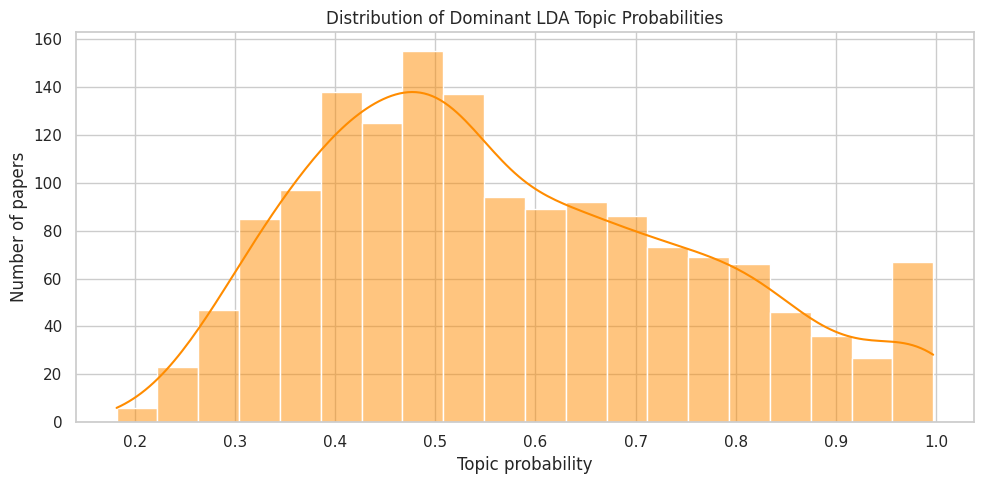

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="LDA_Topic_Probability",
    bins=20,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Dominant LDA Topic Probabilities")
plt.xlabel("Topic probability")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

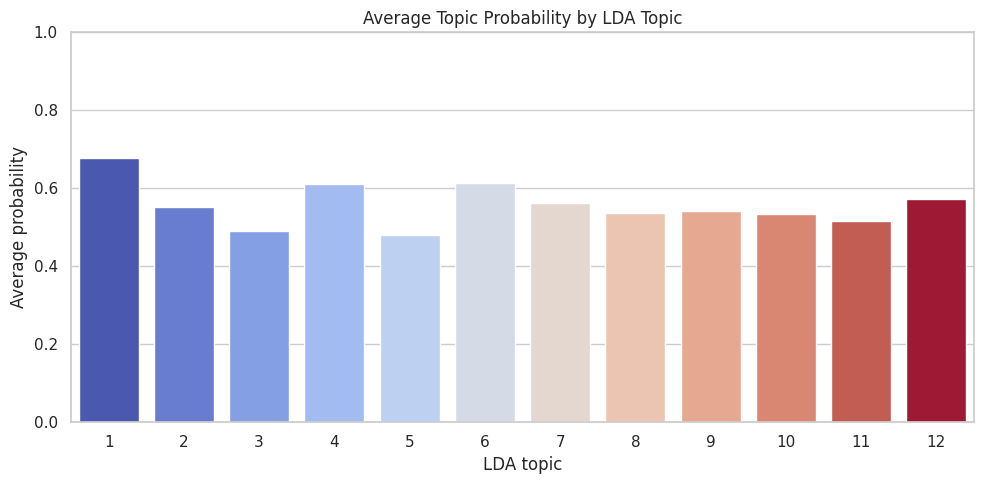

In [ ]:
average_topic_probability = (
    df.groupby("LDA_Topic")["LDA_Topic_Probability"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=average_topic_probability,
    x="LDA_Topic",
    y="LDA_Topic_Probability",
    hue="LDA_Topic",
    palette="coolwarm",
    legend=False
)

plt.title("Average Topic Probability by LDA Topic")
plt.xlabel("LDA topic")
plt.ylabel("Average probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

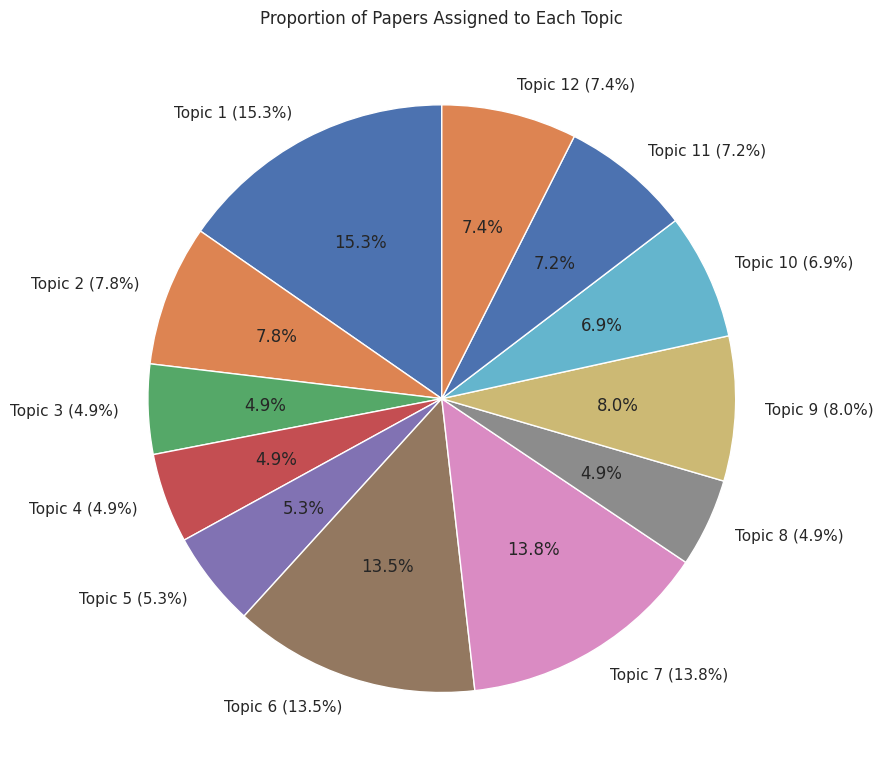

In [ ]:
topic_proportions = (
    df["LDA_Topic"]
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)

topic_proportions.columns = ["Topic", "Proportion"]
topic_proportions["Percentage"] = topic_proportions["Proportion"] * 100

plt.figure(figsize=(9, 9))

plt.pie(
    topic_proportions["Percentage"],
    labels=[
        f"Topic {topic} ({percentage:.1f}%)"
        for topic, percentage in zip(
            topic_proportions["Topic"],
            topic_proportions["Percentage"]
        )
    ],
    startangle=90,
    autopct="%1.1f%%"
)

plt.title("Proportion of Papers Assigned to Each Topic")
plt.tight_layout()
plt.show()

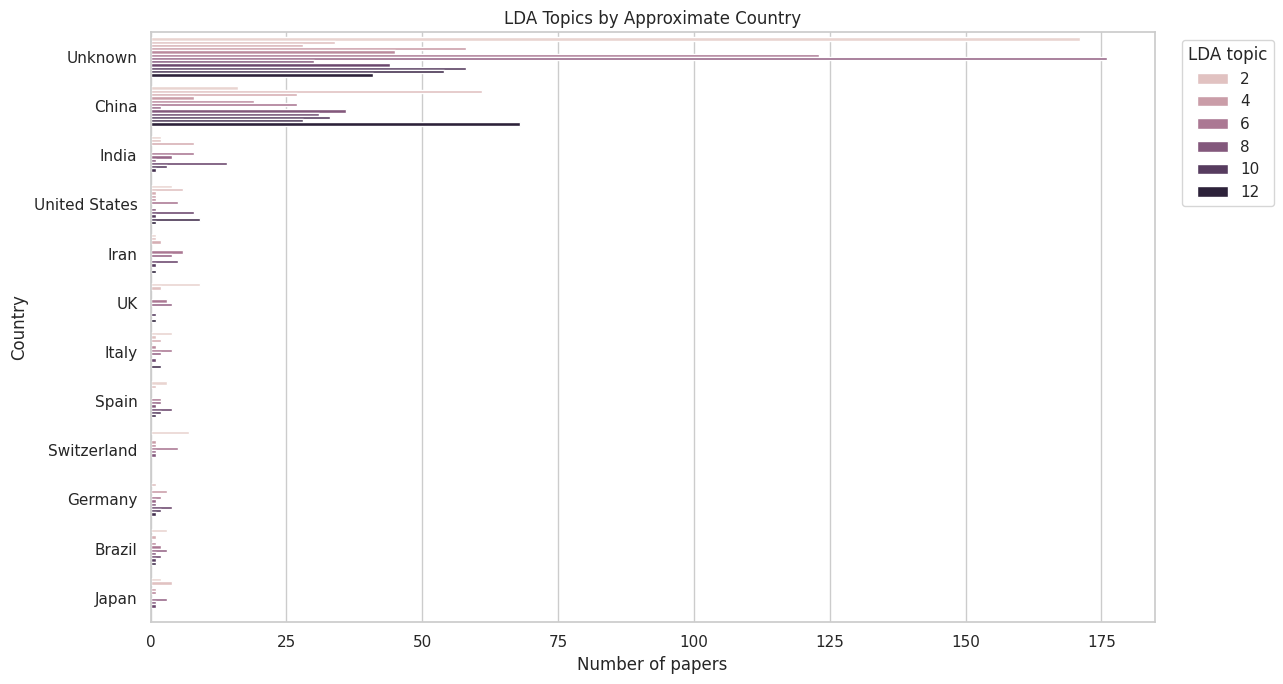

In [ ]:
top_countries = (
    df["Country"]
    .value_counts()
    .head(12)
    .index
)

country_topic_data = df[
    df["Country"].isin(top_countries)
]

plt.figure(figsize=(13, 7))

sns.countplot(
    data=country_topic_data,
    y="Country",
    hue="LDA_Topic",
    order=top_countries
)

plt.title("LDA Topics by Approximate Country")
plt.xlabel("Number of papers")
plt.ylabel("Country")
plt.legend(title="LDA topic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()